[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\b_o_x\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\b_o_x\AppData\Local\Temp\ipykernel_24836\4271056446.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(consulta, conexion)



RESULTADOS - Exp_1

Distribución predicciones:
Exp_1
Positivo    73271
Negativo    10274
Neutro       6446
Name: count, dtype: int64

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.35      0.35      0.35     10244
      Neutro       0.08      0.07      0.07      7270
    Positivo       0.85      0.85      0.85     72477

    accuracy                           0.73     89991
   macro avg       0.42      0.42      0.42     89991
weighted avg       0.73      0.73      0.73     89991


Matriz de confusión:
[[61951  5151  5375]
 [ 5450   501  1319]
 [ 5870   794  3580]]


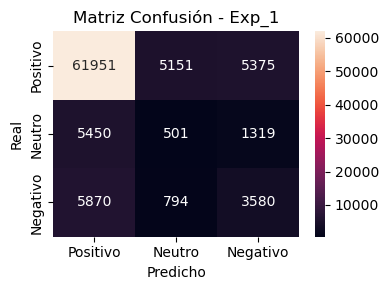


RESULTADOS - Exp_2

Distribución predicciones:
Exp_2
Positivo    72543
Negativo     9681
Neutro       7767
Name: count, dtype: int64

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.35      0.33      0.34     10244
      Neutro       0.08      0.09      0.09      7270
    Positivo       0.85      0.85      0.85     72477

    accuracy                           0.73     89991
   macro avg       0.43      0.42      0.43     89991
weighted avg       0.73      0.73      0.73     89991


Matriz de confusión:
[[61440  6028  5009]
 [ 5376   649  1245]
 [ 5727  1090  3427]]


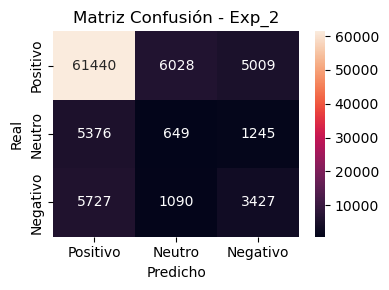


RESULTADOS - Exp_3

Distribución predicciones:
Exp_3
Positivo    70906
Neutro      10552
Negativo     8533
Name: count, dtype: int64

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.37      0.31      0.33     10244
      Neutro       0.09      0.13      0.11      7270
    Positivo       0.85      0.83      0.84     72477

    accuracy                           0.72     89991
   macro avg       0.44      0.42      0.43     89991
weighted avg       0.73      0.72      0.72     89991


Matriz de confusión:
[[60267  7908  4302]
 [ 5194   981  1095]
 [ 5445  1663  3136]]


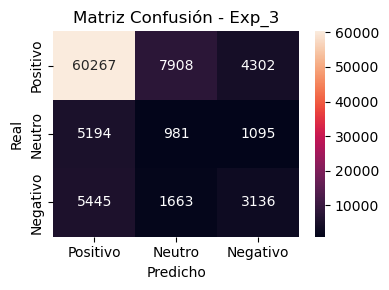


RESULTADOS - Exp_4

Distribución predicciones:
Exp_4
Positivo    68475
Neutro      14569
Negativo     6947
Name: count, dtype: int64

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativo       0.40      0.27      0.32     10244
      Neutro       0.10      0.20      0.13      7270
    Positivo       0.85      0.81      0.83     72477

    accuracy                           0.70     89991
   macro avg       0.45      0.43      0.43     89991
weighted avg       0.74      0.70      0.72     89991


Matriz de confusión:
[[58528 10713  3236]
 [ 4907  1445   918]
 [ 5040  2411  2793]]


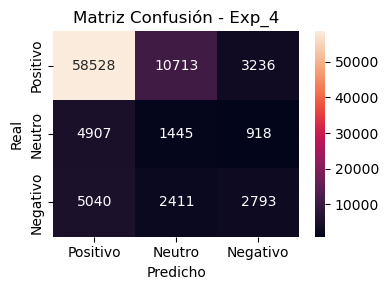


RESUMEN EXPERIMENTACIÓN
  experimento  t_pos  t_neg  accuracy
0       Exp_1   0.05  -0.05  0.733762
1       Exp_2   0.10  -0.10  0.728028
2       Exp_3   0.20  -0.20  0.715449
3       Exp_4   0.30  -0.30  0.697470

MEJOR CONFIGURACIÓN:
Experimento: Exp_1
Umbral positivo: 0.05
Umbral negativo: -0.05
Accuracy: 0.7338

Archivos generados:
resultados_sentimiento.xlsx
dataset_con_sentimiento.xlsx


In [2]:
# =====================================================
# 1. LIBRERÍAS
# =====================================================
import pyodbc
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('vader_lexicon')

# =====================================================
# 2. CONEXIÓN Y CONSULTA
# =====================================================
conexion = pyodbc.connect(
    r"Driver={SQL Server};"
    r"Server=DESKTOP-SDA345T\SQLEXPRESS;"
    r"Database=tpcxbb_1gb;"
    r"Trusted_Connection=yes;"
)

consulta = """
SELECT
    r.pr_review_date AS Fecha_Review,
    r.pr_item_sk AS ID_Producto,
    r.pr_review_rating AS Rating,
    r.pr_review_content AS Texto_Review,
    r.pr_user_sk AS ID_Usuario,
    i.i_category AS Categoria,
    i.i_product_name AS Nombre_Producto,
    i.i_item_desc AS Descripcion,
    i.i_size AS Tamano
FROM product_reviews r
INNER JOIN item i
    ON r.pr_item_sk = i.i_item_sk
"""

df = pd.read_sql(consulta, conexion)

# =====================================================
# 3. PREPARACIÓN
# =====================================================
def limpiar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-zA-Z0-9\s]", "", texto)
    return texto

df["Texto_limpio"] = df["Texto_Review"].fillna("").apply(limpiar)

# =====================================================
# 4. MODELO VADER
# =====================================================
sid = SentimentIntensityAnalyzer()

df["score"] = df["Texto_limpio"].apply(
    lambda x: sid.polarity_scores(x)["compound"]
)

# =====================================================
# 5. VARIABLE REAL (GROUND TRUTH)
# =====================================================
def rating_to_sent(r):
    if r >= 4:
        return "Positivo"
    elif r <= 2:
        return "Negativo"
    else:
        return "Neutro"

df["real"] = df["Rating"].apply(rating_to_sent)

# =====================================================
# 6. FUNCIÓN DE CLASIFICACIÓN
# =====================================================
def clasificar(score, t_pos, t_neg):
    if score >= t_pos:
        return "Positivo"
    elif score <= t_neg:
        return "Negativo"
    else:
        return "Neutro"

# =====================================================
# 7. EXPERIMENTOS (HIPERPARÁMETROS)
# =====================================================
experimentos = [
    {"nombre": "Exp_1", "t_pos": 0.05, "t_neg": -0.05},
    {"nombre": "Exp_2", "t_pos": 0.10, "t_neg": -0.10},
    {"nombre": "Exp_3", "t_pos": 0.20, "t_neg": -0.20},
    {"nombre": "Exp_4", "t_pos": 0.30, "t_neg": -0.30}
]

resultados = []

# =====================================================
# 8. LOOP DE EXPERIMENTACIÓN
# =====================================================
for exp in experimentos:

    nombre = exp["nombre"]

    df[nombre] = df["score"].apply(
        lambda x: clasificar(x, exp["t_pos"], exp["t_neg"])
    )

    acc = accuracy_score(df["real"], df[nombre])

    resultados.append({
        "experimento": nombre,
        "t_pos": exp["t_pos"],
        "t_neg": exp["t_neg"],
        "accuracy": acc
    })

    # =========================
    # REPORTE DETALLADO
    # =========================
    print("\n" + "="*60)
    print(f"RESULTADOS - {nombre}")
    print("="*60)

    print("\nDistribución predicciones:")
    print(df[nombre].value_counts())

    print("\nReporte de clasificación:")
    print(classification_report(df["real"], df[nombre]))

    print("\nMatriz de confusión:")
    matriz = confusion_matrix(
        df["real"],
        df[nombre],
        labels=["Positivo","Neutro","Negativo"]
    )
    print(matriz)

    # =========================
    # GRÁFICO MATRIZ
    # =========================
    plt.figure(figsize=(4,3))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        xticklabels=["Positivo","Neutro","Negativo"],
        yticklabels=["Positivo","Neutro","Negativo"]
    )
    plt.title(f"Matriz Confusión - {nombre}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

# =====================================================
# 9. RESULTADOS GENERALES
# =====================================================
resultados_df = pd.DataFrame(resultados)

print("\n" + "="*60)
print("RESUMEN EXPERIMENTACIÓN")
print("="*60)

print(resultados_df.sort_values(by="accuracy", ascending=False))

# =====================================================
# 10. MEJOR MODELO
# =====================================================
mejor = resultados_df.sort_values(by="accuracy", ascending=False).iloc[0]

print("\nMEJOR CONFIGURACIÓN:")
print(f"Experimento: {mejor['experimento']}")
print(f"Umbral positivo: {mejor['t_pos']}")
print(f"Umbral negativo: {mejor['t_neg']}")
print(f"Accuracy: {round(mejor['accuracy'],4)}")

# =====================================================
# 11. EXPORTAR RESULTADOS
# =====================================================
resultados_df.to_excel("resultados_sentimiento.xlsx", index=False)
df.to_excel("dataset_con_sentimiento.xlsx", index=False)

print("\nArchivos generados:")
print("resultados_sentimiento.xlsx")
print("dataset_con_sentimiento.xlsx")

conexion.close()